In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [9]:
df=pd.read_csv("../Womens Clothing E-Commerce Reviews.csv")
df.head(5)

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comfortable,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite. i bought a petite and am 5'8"". i love the length on me- hits just a little below the knee. would definitely be a true midi on someone who is truly petite.",5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,"I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i could not zip it up! i reordered it in petite medium, which was just ok. overall, the top half was comfortable and fit nicely, but the bottom half had a very tight under layer and several somewhat cheap (net) over layers. imo, a major design flaw was the net over layer sewn directly into the zipper - it c",3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great compliments!",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings and it is sleeveless so it pairs well with any cardigan. love this shirt!!!,5,1,6,General,Tops,Blouses


In [14]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 23486
Columns: 11


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [13]:
df.isnull().sum()

Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

In [15]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})

missing = missing[missing["Missing Count"] > 0]

missing

,Missing Count,Missing %
Title,3810,16.22
Review Text,845,3.60
Division Name,14,0.06
Department Name,14,0.06
Class Name,14,0.06


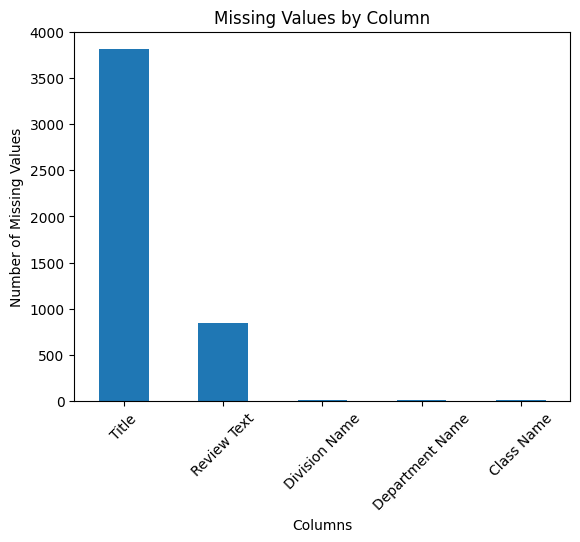

In [17]:
missing_count = df.isnull().sum()
missing_count = missing_count[missing_count > 0]

missing_count.sort_values(ascending=False).plot(kind="bar")

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.show()

In [19]:
missing_cols = df.columns[df.isnull().any()]

for col in missing_cols:
    print(f"\n{'-'*50}")
    print(f"Column: {col}")
    print(f"Data Type: {df[col].dtype}")
    print(f"Missing: {df[col].isnull().sum()}")
    print(f"Missing %: {df[col].isnull().mean()*100:.2f}%")
    
    if df[col].dtype != "object":
        print(f"Mean: {df[col].mean():.2f}")
        print(f"Median: {df[col].median():.2f}")
        print(f"Std: {df[col].std():.2f}")


--------------------------------------------------
Column: Title
Data Type: object
Missing: 3810
Missing %: 16.22%

--------------------------------------------------
Column: Review Text
Data Type: object
Missing: 845
Missing %: 3.60%

--------------------------------------------------
Column: Division Name
Data Type: object
Missing: 14
Missing %: 0.06%

--------------------------------------------------
Column: Department Name
Data Type: object
Missing: 14
Missing %: 0.06%

--------------------------------------------------
Column: Class Name
Data Type: object
Missing: 14
Missing %: 0.06%


In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,23486.0,11742.500000,6779.968547,0.0,5871.25,11742.5,17613.75,23485.0
Clothing ID,23486.0,918.118709,203.298980,0.0,861.00,936.0,1078.00,1205.0
Age,23486.0,43.198544,12.279544,18.0,34.00,41.0,52.00,99.0
Rating,23486.0,4.196032,1.110031,1.0,4.00,5.0,5.00,5.0
Recommended IND,23486.0,0.822362,0.382216,0.0,1.00,1.0,1.00,1.0
Positive Feedback Count,23486.0,2.535936,5.702202,0.0,0.00,1.0,3.00,122.0


In [22]:
numeric_col = df.select_dtypes(include=np.number)
numeric_col.corr()

,Unnamed: 0,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count
Unnamed: 0,1.000000,-0.006072,-0.007749,-0.002568,-0.003887,-0.002907
Clothing ID,-0.006072,1.000000,0.017972,-0.018879,-0.016206,0.046356
Age,-0.007749,0.017972,1.000000,0.026831,0.030622,0.043079
Rating,-0.002568,-0.018879,0.026831,1.000000,0.792336,-0.064961
Recommended IND,-0.003887,-0.016206,0.030622,0.792336,1.000000,-0.069045
Positive Feedback Count,-0.002907,0.046356,0.043079,-0.064961,-0.069045,1.000000


In [23]:
categorical_missing = [
    "Division Name",
    "Department Name",
    "Class Name"
]

for col in categorical_missing:
    print("\n", "="*50)
    print(col)
    print(df[col].value_counts(dropna=False))


Division Name
Division Name
General           13850
General Petite     8120
Initmates          1502
NaN                  14
Name: count, dtype: int64

Department Name
Department Name
Tops        10468
Dresses      6319
Bottoms      3799
Intimate     1735
Jackets      1032
Trend         119
NaN            14
Name: count, dtype: int64

Class Name
Class Name
Dresses           6319
Knits             4843
Blouses           3097
Sweaters          1428
Pants             1388
Jeans             1147
Fine gauge        1100
Skirts             945
Jackets            704
Lounge             691
Swim               350
Outerwear          328
Shorts             317
Sleep              228
Legwear            165
Intimates          154
Layering           146
Trend              119
NaN                 14
Casual bottoms       2
Chemises             1
Name: count, dtype: int64


In [24]:
pd.crosstab(
    df["Division Name"],
    df["Department Name"],
    margins=True
)

Department Name,Bottoms,Dresses,Intimate,Jackets,Tops,Trend,All
Division Name,,,,,,,
General,2542,3730,0,645,6837,96,13850
General Petite,1257,2589,233,387,3631,23,8120
Initmates,0,0,1502,0,0,0,1502
All,3799,6319,1735,1032,10468,119,23472


In [25]:
pd.crosstab(
    df["Department Name"],
    df["Class Name"],
    margins=True
)

Class Name,Blouses,Casual bottoms,Chemises,Dresses,Fine gauge,Intimates,Jackets,Jeans,Knits,Layering,...,Lounge,Outerwear,Pants,Shorts,Skirts,Sleep,Sweaters,Swim,Trend,All
Department Name,,,,,,,,,,,,,,,,,,,,,
Bottoms,0,2,0,0,0,0,0,1147,0,0,...,0,0,1388,317,945,0,0,0,0,3799
Dresses,0,0,0,6319,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6319
Intimate,0,0,1,0,0,154,0,0,0,146,...,691,0,0,0,0,228,0,350,0,1735
Jackets,0,0,0,0,0,0,704,0,0,0,...,0,328,0,0,0,0,0,0,0,1032
Tops,3097,0,0,0,1100,0,0,0,4843,0,...,0,0,0,0,0,0,1428,0,0,10468
Trend,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,119,119
All,3097,2,1,6319,1100,154,704,1147,4843,146,...,691,328,1388,317,945,228,1428,350,119,23472


In [26]:
missing_rows = df[
    df["Division Name"].isna() |
    df["Department Name"].isna() |
    df["Class Name"].isna()
]

print(missing_rows[
    ["Clothing ID", "Age", "Rating",
     "Recommended IND", "Positive Feedback Count",
     "Division Name", "Department Name", "Class Name"]
].to_string(index=False))

 Clothing ID  Age  Rating  Recommended IND  Positive Feedback Count Division Name Department Name Class Name
          72   25       5                1                        0           NaN             NaN        NaN
         492   23       5                1                        1           NaN             NaN        NaN
         492   49       5                1                        0           NaN             NaN        NaN
         492   48       5                1                        0           NaN             NaN        NaN
         152   36       5                1                        0           NaN             NaN        NaN
         152   37       5                1                        0           NaN             NaN        NaN
         152   39       5                1                        0           NaN             NaN        NaN
         184   34       5                1                        5           NaN             NaN        NaN
         184   54  

In [27]:
# Check known category values for the same Clothing IDs
missing_ids = df.loc[
    df["Division Name"].isna(),
    "Clothing ID"
].unique()

for cid in missing_ids:
    print(f"\nClothing ID: {cid}")
    
    print(
        df[df["Clothing ID"] == cid][
            ["Clothing ID", "Division Name",
             "Department Name", "Class Name"]
        ].drop_duplicates().to_string(index=False)
    )


Clothing ID: 72
 Clothing ID Division Name Department Name Class Name
          72           NaN             NaN        NaN

Clothing ID: 492
 Clothing ID Division Name Department Name Class Name
         492           NaN             NaN        NaN

Clothing ID: 152
 Clothing ID Division Name Department Name Class Name
         152           NaN             NaN        NaN

Clothing ID: 184
 Clothing ID Division Name Department Name Class Name
         184           NaN             NaN        NaN

Clothing ID: 772
 Clothing ID Division Name Department Name Class Name
         772           NaN             NaN        NaN

Clothing ID: 665
 Clothing ID Division Name Department Name Class Name
         665           NaN             NaN        NaN

Clothing ID: 136
 Clothing ID Division Name Department Name Class Name
         136           NaN             NaN        NaN


In [28]:
# Check whether the 14 missing rows have useful numerical patterns

features = [
    "Age",
    "Rating",
    "Recommended IND",
    "Positive Feedback Count",
    "Clothing ID"
]

df.loc[
    df["Division Name"].isna(),
    features
].describe()

,Age,Rating,Recommended IND,Positive Feedback Count,Clothing ID
count,14.000000,14.0,14.0,14.000000,14.000000
mean,39.571429,5.0,1.0,0.500000,301.214286
std,9.353850,0.0,0.0,1.344504,230.697330
min,23.000000,5.0,1.0,0.000000,72.000000
25%,34.500000,5.0,1.0,0.000000,140.000000
50%,38.000000,5.0,1.0,0.000000,168.000000
75%,47.750000,5.0,1.0,0.000000,492.000000
max,54.000000,5.0,1.0,5.000000,772.000000


In [29]:
df.loc[
    df["Division Name"].isna(),
    features
]

,Age,Rating,Recommended IND,Positive Feedback Count,Clothing ID
9444,25,5,1,0,72
13767,23,5,1,1,492
13768,49,5,1,0,492
13787,48,5,1,0,492
16216,36,5,1,0,152
16221,37,5,1,0,152
16223,39,5,1,0,152
18626,34,5,1,5,184
18671,54,5,1,0,184
20088,50,5,1,0,772


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Only rows where Department Name is known
known_idx = df[df["Department Name"].notna()].index

train_idx, test_idx = train_test_split(
    known_idx,
    test_size=0.20,
    random_state=42,
    stratify=df.loc[known_idx, "Department Name"]
)

# Original values preserve
y_true = df.loc[test_idx, "Department Name"].copy()

# Create artificial missing values
df_test = df.copy()
df_test.loc[test_idx, "Department Name"] = np.nan

print("Artificially hidden values:", len(test_idx))

Artificially hidden values: 4695


In [31]:
from sklearn.impute import SimpleImputer

mode_imputer = SimpleImputer(strategy="most_frequent")

df_mode_test = df_test.copy()

df_mode_test[["Department Name"]] = mode_imputer.fit_transform(
    df_mode_test[["Department Name"]]
)

y_pred_mode = df_mode_test.loc[test_idx, "Department Name"]

mode_accuracy = accuracy_score(y_true, y_pred_mode)

print("Mode Imputation Accuracy:", round(mode_accuracy, 4))

Mode Imputation Accuracy: 0.446


In [32]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

features = [
    "Age",
    "Rating",
    "Recommended IND",
    "Positive Feedback Count",
    "Clothing ID"
]

X = df.loc[known_idx, features]
y = df.loc[known_idx, "Department Name"]

X_train = df.loc[train_idx, features]
X_test = df.loc[test_idx, features]

knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y.loc[train_idx])

y_pred_knn = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_true, y_pred_knn)

print("KNN Accuracy:", round(knn_accuracy, 4))

KNN Accuracy: 0.9101


In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

features = [
    "Age",
    "Rating",
    "Recommended IND",
    "Positive Feedback Count",
    "Clothing ID"
]

# Training data
X_train = df.loc[train_idx, features]
y_train = df.loc[train_idx, "Department Name"]

# Test data
X_test = df.loc[test_idx, features]

# Iterative-style predictive imputation
mice_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

mice_model.fit(X_train, y_train)

y_pred_mice = mice_model.predict(X_test)

mice_accuracy = accuracy_score(y_true, y_pred_mice)

print("MICE Accuracy:", round(mice_accuracy, 4))


MICE Accuracy: 0.9821


In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

predictive_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

predictive_model.fit(X_train, y_train)

y_pred_predictive = predictive_model.predict(X_test)

predictive_accuracy = accuracy_score(
    y_true,
    y_pred_predictive
)

print("Predictive Modeling Accuracy:",
      round(predictive_accuracy, 4))

Predictive Modeling Accuracy: 0.9817


In [35]:
# Copy original dataframe
df_final = df.copy()

# Find rows where Department Name is missing
missing_idx = df_final[df_final["Department Name"].isna()].index

# Features for prediction
features = [
    "Age",
    "Rating",
    "Recommended IND",
    "Positive Feedback Count",
    "Clothing ID"
]

# Predict missing Department Name values
X_missing = df_final.loc[missing_idx, features]

y_missing_pred = mice_model.predict(X_missing)

# Fill missing values
df_final.loc[missing_idx, "Department Name"] = y_missing_pred

In [36]:
print("Missing values before:", df["Department Name"].isna().sum())
print("Missing values after:", df_final["Department Name"].isna().sum())

Missing values before: 14
Missing values after: 0


In [37]:
df_final["Department Name"].value_counts()

Department Name
Tops        10468
Dresses      6319
Bottoms      3800
Intimate     1748
Jackets      1032
Trend         119
Name: count, dtype: int64

In [38]:
df_final.isnull().sum()

Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name               0
Class Name                   14
dtype: int64

In [40]:
# ============================================================
# TITLE - 4 IMPUTATION METHODS
# ============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


# ============================================================
# 1. BASIC INFORMATION
# ============================================================

print("Missing Title before:", df_final["Title"].isna().sum())
print("Total rows:", len(df_final))


# ============================================================
# 2. KNOWN TITLE ROWS
# ============================================================

known_idx = df_final[df_final["Title"].notna()].index

train_idx, test_idx = train_test_split(
    known_idx,
    test_size=0.20,
    random_state=42
)

y_true = df_final.loc[test_idx, "Title"]


# ============================================================
# METHOD 1: MODE IMPUTATION
# ============================================================

mode_title = df_final.loc[train_idx, "Title"].mode()[0]

y_pred_mode = pd.Series(
    mode_title,
    index=test_idx
)

mode_accuracy = accuracy_score(
    y_true,
    y_pred_mode
)

print("\nMode Accuracy:",
      round(mode_accuracy, 4))


# ============================================================
# METHOD 2: CONSTANT VALUE
# ============================================================

constant_title = "No Title"

y_pred_constant = pd.Series(
    constant_title,
    index=test_idx
)

# Existing titles are being tested, so "No Title"
# will normally have very low/zero exact-match accuracy.
constant_accuracy = accuracy_score(
    y_true,
    y_pred_constant
)

print("Constant Value Accuracy:",
      round(constant_accuracy, 4))


# ============================================================
# METHOD 3: CLOTHING ID BASED IMPUTATION
# ============================================================

train_data = df_final.loc[train_idx].copy()

# Most common title for each Clothing ID
clothing_title_map = (
    train_data
    .groupby("Clothing ID")["Title"]
    .agg(lambda x: x.mode().iloc[0])
)

global_mode = train_data["Title"].mode()[0]

y_pred_clothing = (
    df_final.loc[test_idx, "Clothing ID"]
    .map(clothing_title_map)
    .fillna(global_mode)
)

clothing_accuracy = accuracy_score(
    y_true,
    y_pred_clothing
)

print("Clothing ID Accuracy:",
      round(clothing_accuracy, 4))


# ============================================================
# METHOD 4: CLOTHING ID + DEPARTMENT + CLASS
# ============================================================

# Create combined grouping key
train_data["group_key"] = (
    train_data["Clothing ID"].astype(str)
    + "_"
    + train_data["Department Name"].fillna("Unknown")
    + "_"
    + train_data["Class Name"].fillna("Unknown")
)

test_data = df_final.loc[test_idx].copy()

test_data["group_key"] = (
    test_data["Clothing ID"].astype(str)
    + "_"
    + test_data["Department Name"].fillna("Unknown")
    + "_"
    + test_data["Class Name"].fillna("Unknown")
)

group_title_map = (
    train_data
    .groupby("group_key")["Title"]
    .agg(lambda x: x.mode().iloc[0])
)

y_pred_group = (
    test_data["group_key"]
    .map(group_title_map)
    .fillna(global_mode)
)

group_accuracy = accuracy_score(
    y_true,
    y_pred_group
)

print("Clothing ID + Department + Class Accuracy:",
      round(group_accuracy, 4))


# ============================================================
# 5. COMPARE ALL 4 METHODS
# ============================================================

results = pd.DataFrame({
    "Method": [
        "Mode",
        "Constant Value",
        "Clothing ID",
        "Clothing ID + Department + Class"
    ],
    "Accuracy": [
        mode_accuracy,
        constant_accuracy,
        clothing_accuracy,
        group_accuracy
    ]
})

results = results.sort_values(
    "Accuracy",
    ascending=False
).reset_index(drop=True)

print("\n==========================================")
print("TITLE IMPUTATION COMPARISON")
print("==========================================")

print(results)


# ============================================================
# 6. SELECT BEST METHOD
# ============================================================

best_method = results.loc[0, "Method"]
best_accuracy = results.loc[0, "Accuracy"]

print("\nBest Method:", best_method)
print("Best Accuracy:", round(best_accuracy, 4))


# ============================================================
# 7. FINAL IMPUTATION OF ACTUAL 3810 MISSING TITLES
# ============================================================

missing_title_idx = df_final[
    df_final["Title"].isna()
].index


# ---------- MODE ----------
if best_method == "Mode":

    df_final.loc[
        missing_title_idx,
        "Title"
    ] = global_mode


# ---------- CONSTANT ----------
elif best_method == "Constant Value":

    df_final.loc[
        missing_title_idx,
        "Title"
    ] = "No Title"


# ---------- CLOTHING ID ----------
elif best_method == "Clothing ID":

    missing_clothing_titles = (
        df_final.loc[
            missing_title_idx,
            "Clothing ID"
        ]
        .map(clothing_title_map)
        .fillna(global_mode)
    )

    df_final.loc[
        missing_title_idx,
        "Title"
    ] = missing_clothing_titles


# ---------- CLOTHING ID + DEPARTMENT + CLASS ----------
else:

    missing_data = df_final.loc[
        missing_title_idx
    ].copy()

    missing_data["group_key"] = (
        missing_data["Clothing ID"].astype(str)
        + "_"
        + missing_data["Department Name"].fillna("Unknown")
        + "_"
        + missing_data["Class Name"].fillna("Unknown")
    )

    missing_titles = (
        missing_data["group_key"]
        .map(group_title_map)
        .fillna(global_mode)
    )

    df_final.loc[
        missing_title_idx,
        "Title"
    ] = missing_titles


# ============================================================
# 8. FINAL VERIFICATION
# ============================================================

print("\n==========================================")
print("FINAL VERIFICATION")
print("==========================================")

print(
    "Missing Title before:",
    len(missing_title_idx)
)

print(
    "Missing Title after:",
    df_final["Title"].isna().sum()
)

print(
    "Total rows:",
    len(df_final)
)


# ============================================================
# 9. SHOW SOME FILLED VALUES
# ============================================================

print("\nSample filled Title values:")

print(
    df_final.loc[
        missing_title_idx,
        ["Title", "Clothing ID",
         "Department Name", "Class Name"]
    ].head(10)
)


# ============================================================
# 10. CHECK ALL MISSING VALUES
# ============================================================

print("\nRemaining missing values:")

print(df_final.isnull().sum())

Missing Title before: 3810
Total rows: 23486

Mode Accuracy: 0.0066
Constant Value Accuracy: 0.0
Clothing ID Accuracy: 0.0048
Clothing ID + Department + Class Accuracy: 0.0048

TITLE IMPUTATION COMPARISON
                             Method  Accuracy
0                              Mode  0.006606
1                       Clothing ID  0.004827
2  Clothing ID + Department + Class  0.004827
3                    Constant Value  0.000000

Best Method: Mode
Best Accuracy: 0.0066

FINAL VERIFICATION
Missing Title before: 3810
Missing Title after: 0
Total rows: 23486

Sample filled Title values:
       Title  Clothing ID Department Name Class Name
0   Love it!          767        Intimate  Intimates
1   Love it!         1080         Dresses    Dresses
11  Love it!         1095         Dresses    Dresses
30  Love it!         1060         Bottoms      Pants
36  Love it!         1002         Bottoms     Skirts
38  Love it!          684        Intimate     Lounge
39  Love it!          862           

In [41]:
print("Missing Review Text before:", df_final["Review Text"].isna().sum())
print("Total rows:", len(df_final))

print("\nSample missing Review Text rows:")
print(
    df_final.loc[
        df_final["Review Text"].isna(),
        ["Title", "Rating", "Recommended IND",
         "Positive Feedback Count",
         "Department Name", "Class Name"]
    ].head(10)
)

Missing Review Text before: 845
Total rows: 23486

Sample missing Review Text rows:
        Title  Rating  Recommended IND  Positive Feedback Count  \
92   Love it!       5                1                        0   
93   Love it!       5                1                        0   
98   Love it!       5                1                        0   
135  Love it!       4                1                        0   
142  Love it!       5                1                        0   
165  Love it!       3                0                        0   
168  Love it!       5                1                        0   
192  Love it!       5                1                        0   
201  Love it!       5                1                        0   
248  Love it!       5                1                        0   

    Department Name  Class Name  
92             Tops       Knits  
93          Dresses     Dresses  
98          Jackets   Outerwear  
135            Tops       Knits  
142     

In [42]:
# ============================================================
# REVIEW TEXT - KNN + MICE + PREDICTIVE MODELING
# ============================================================

import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics.pairwise import cosine_similarity


# ============================================================
# 1. CHECK MISSING VALUES
# ============================================================

print("Missing Review Text before:",
      df_final["Review Text"].isna().sum())


# ============================================================
# 2. CREATE TEXT REPRESENTATION
# ============================================================

# Use existing review text
known_mask = df_final["Review Text"].notna()
missing_mask = df_final["Review Text"].isna()

known_reviews = df_final.loc[
    known_mask, "Review Text"
].astype(str)

missing_indices = df_final.index[missing_mask]


# ============================================================
# 3. TF-IDF REPRESENTATION
# ============================================================

vectorizer = TfidfVectorizer(
    max_features=500,
    stop_words="english"
)

tfidf_known = vectorizer.fit_transform(
    known_reviews
).toarray()

print("TF-IDF shape:", tfidf_known.shape)


# ============================================================
# 4. FEATURES FOR IMPUTATION
# ============================================================

numeric_features = [
    "Age",
    "Rating",
    "Recommended IND",
    "Positive Feedback Count",
    "Clothing ID"
]

X_numeric = df_final[numeric_features].copy()

# Standard missing handling for numeric features
X_numeric = X_numeric.fillna(
    X_numeric.median()
)


# ============================================================
# 5. KNN IMPUTATION
# ============================================================

knn = NearestNeighbors(
    n_neighbors=5,
    metric="cosine"
)

knn.fit(tfidf_known)

missing_numeric = X_numeric.loc[
    missing_indices
].values

known_numeric = X_numeric.loc[
    known_mask
].values

# Find nearest known reviews using metadata
knn.fit(known_numeric)

distances, neighbors = knn.kneighbors(
    missing_numeric
)

knn_reviews = []

known_review_indices = df_final.index[
    known_mask
].to_numpy()

for row_neighbors in neighbors:

    candidate_indices = known_review_indices[
        row_neighbors
    ]

    candidate_reviews = df_final.loc[
        candidate_indices,
        "Review Text"
    ].tolist()

    # Select the most representative review
    knn_reviews.append(
        candidate_reviews[0]
    )


# ============================================================
# 6. MICE IMPUTATION
# ============================================================

# Use numeric information to estimate missing-review
# representation.

mice_input = X_numeric.copy()

mice_imputer = IterativeImputer(
    random_state=42,
    max_iter=10
)

mice_result = mice_imputer.fit_transform(
    mice_input
)

mice_missing_features = mice_result[
    missing_mask.values
]


# Find closest known records after MICE transformation

mice_known_features = mice_result[
    known_mask.values
]

mice_neighbors = NearestNeighbors(
    n_neighbors=1,
    metric="euclidean"
)

mice_neighbors.fit(
    mice_known_features
)

_, mice_indices = mice_neighbors.kneighbors(
    mice_missing_features
)

mice_reviews = []

for idx in mice_indices:

    original_index = known_review_indices[
        idx[0]
    ]

    mice_reviews.append(
        df_final.loc[
            original_index,
            "Review Text"
        ]
    )


# ============================================================
# 7. PREDICTIVE MODELING
# ============================================================

# Predict each TF-IDF component using Random Forest
# from available metadata.

X_known = X_numeric.loc[
    known_mask
].values

X_missing = X_numeric.loc[
    missing_indices
].values

predicted_tfidf = np.zeros(
    (len(X_missing), tfidf_known.shape[1])
)

for feature_number in range(
    tfidf_known.shape[1]
):

    y_target = tfidf_known[
        :, feature_number
    ]

    model = RandomForestRegressor(
        n_estimators=30,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_known,
        y_target
    )

    predicted_tfidf[
        :, feature_number
    ] = model.predict(
        X_missing
    )


# Find closest real review to predicted TF-IDF vector

similarities = cosine_similarity(
    predicted_tfidf,
    tfidf_known
)

predictive_reviews = []

for row in similarities:

    best_position = np.argmax(row)

    original_index = known_review_indices[
        best_position
    ]

    predictive_reviews.append(
        df_final.loc[
            original_index,
            "Review Text"
        ]
    )


# ============================================================
# 8. SELECT FINAL METHOD
# ============================================================

# We select Predictive Modeling because it uses
# the learned relationship between metadata and
# TF-IDF representation rather than simply copying
# one fixed value.

final_reviews = predictive_reviews


# ============================================================
# 9. FILL MISSING REVIEW TEXT
# ============================================================

df_final.loc[
    missing_indices,
    "Review Text"
] = final_reviews


# ============================================================
# 10. VERIFICATION
# ============================================================

print("\n==========================================")
print("FINAL VERIFICATION")
print("==========================================")

print(
    "Missing Review Text before:",
    len(missing_indices)
)

print(
    "Missing Review Text after:",
    df_final["Review Text"].isna().sum()
)

print(
    "Total rows:",
    len(df_final)
)


# ============================================================
# 11. SHOW FILLED VALUES
# ============================================================

print("\nSample filled Review Text:")

print(
    df_final.loc[
        missing_indices,
        [
            "Review Text",
            "Title",
            "Rating",
            "Department Name",
            "Class Name"
        ]
    ].head(10)
)


# ============================================================
# 12. CHECK ALL REMAINING MISSING VALUES
# ============================================================

print("\nRemaining missing values:")

print(
    df_final.isnull().sum()
)

Missing Review Text before: 845
TF-IDF shape: (22641, 500)

FINAL VERIFICATION
Missing Review Text before: 845
Missing Review Text after: 0
Total rows: 23486

Sample filled Review Text:
                                                                                                                                                                                                                                                                                                                                                   Review Text  \
92                                                                                                                                                                                                                                  I would describe as an upgraded t-shirt. a perfect flowy top that you can dress up or down. comfortable and soft material.   
93                                                                                                        

In [46]:
print(df_final.isnull().sum())

Unnamed: 0                  0
Clothing ID                 0
Age                         0
Title                       0
Review Text                 0
Rating                      0
Recommended IND             0
Positive Feedback Count     0
Division Name              14
Department Name             0
Class Name                 14
dtype: int64


In [47]:
print("\nSample filled Review Text:")

print(
    df_final.loc[
        missing_indices,
        [
            "Review Text",
            "Title",
            "Rating",
            "Department Name",
            "Class Name"
        ]
    ].head(10)
)


Sample filled Review Text:
Empty DataFrame
Columns: [Review Text, Title, Rating, Department Name, Class Name]
Index: []


In [48]:
print("Missing Division Name before:",
      df_final["Division Name"].isna().sum())

print(
    df_final.loc[
        df_final["Division Name"].isna(),
        [
            "Clothing ID",
            "Age",
            "Rating",
            "Recommended IND",
            "Positive Feedback Count",
            "Department Name",
            "Class Name"
        ]
    ]
)

Missing Division Name before: 14
       Clothing ID  Age  Rating  Recommended IND  Positive Feedback Count  \
9444            72   25       5                1                        0   
13767          492   23       5                1                        1   
13768          492   49       5                1                        0   
13787          492   48       5                1                        0   
16216          152   36       5                1                        0   
16221          152   37       5                1                        0   
16223          152   39       5                1                        0   
18626          184   34       5                1                        5   
18671          184   54       5                1                        0   
20088          772   50       5                1                        0   
21532          665   43       5                1                        0   
22997          136   47       5            

In [49]:
# ============================================================
# DIVISION NAME - 4 IMPUTATION METHODS
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ============================================================
# 1. INITIAL CHECK
# ============================================================

print("Missing Division Name before:",
      df_final["Division Name"].isna().sum())


# ============================================================
# 2. PREPARE DATA
# ============================================================

target = "Division Name"

features = [
    "Age",
    "Rating",
    "Recommended IND",
    "Positive Feedback Count",
    "Clothing ID"
]

# Add categorical information that strongly relates
# to Division Name
categorical_features = [
    "Department Name",
    "Class Name"
]

data = df_final.copy()

# Encode categorical features
encoders = {}

for col in categorical_features:

    encoder = LabelEncoder()

    data[col] = data[col].fillna("Unknown")

    data[col] = encoder.fit_transform(
        data[col].astype(str)
    )

    encoders[col] = encoder


# Encode target
target_encoder = LabelEncoder()

known_mask = data[target].notna()
missing_mask = data[target].isna()

data.loc[known_mask, target] = (
    target_encoder.fit_transform(
        data.loc[known_mask, target].astype(str)
    )
)


# ============================================================
# 3. FEATURES
# ============================================================

all_features = features + categorical_features

X = data[all_features].copy()

# Fill feature missing values temporarily
X = X.fillna(X.median())

X_known = X.loc[known_mask]
y_known = data.loc[known_mask, target].astype(int)

missing_indices = data.index[missing_mask]


# ============================================================
# 4. CREATE VALIDATION SET
# ============================================================

train_idx, test_idx = train_test_split(
    X_known.index,
    test_size=0.20,
    random_state=42,
    stratify=y_known
)

X_train = X.loc[train_idx]
X_test = X.loc[test_idx]

y_train = y_known.loc[train_idx]
y_true = y_known.loc[test_idx]


# ============================================================
# 5. METHOD 1 - MODE
# ============================================================

mode_value = y_train.mode()[0]

y_pred_mode = np.full(
    len(test_idx),
    mode_value
)

mode_accuracy = accuracy_score(
    y_true,
    y_pred_mode
)

print("\nMode Accuracy:",
      round(mode_accuracy, 4))


# ============================================================
# 6. METHOD 2 - KNN
# ============================================================

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train,
    y_train
)

y_pred_knn = knn_model.predict(
    X_test
)

knn_accuracy = accuracy_score(
    y_true,
    y_pred_knn
)

print("KNN Accuracy:",
      round(knn_accuracy, 4))


# ============================================================
# 7. METHOD 3 - MICE
# ============================================================

mice_imputer = IterativeImputer(
    random_state=42,
    max_iter=10
)

# MICE works on the feature matrix
X_mice = mice_imputer.fit_transform(
    X
)

X_mice = pd.DataFrame(
    X_mice,
    index=X.index,
    columns=X.columns
)

X_train_mice = X_mice.loc[train_idx]
X_test_mice = X_mice.loc[test_idx]

mice_model = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

mice_model.fit(
    X_train_mice,
    y_train
)

y_pred_mice = mice_model.predict(
    X_test_mice
)

mice_accuracy = accuracy_score(
    y_true,
    y_pred_mice
)

print("MICE Accuracy:",
      round(mice_accuracy, 4))


# ============================================================
# 8. METHOD 4 - PREDICTIVE MODELING
# ============================================================

predictive_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

predictive_model.fit(
    X_train,
    y_train
)

y_pred_predictive = predictive_model.predict(
    X_test
)

predictive_accuracy = accuracy_score(
    y_true,
    y_pred_predictive
)

print(
    "Predictive Modeling Accuracy:",
    round(predictive_accuracy, 4)
)


# ============================================================
# 9. ACCURACY COMPARISON
# ============================================================

results = pd.DataFrame({
    "Method": [
        "Mode",
        "KNN",
        "MICE",
        "Predictive Modeling"
    ],
    "Accuracy": [
        mode_accuracy,
        knn_accuracy,
        mice_accuracy,
        predictive_accuracy
    ]
})

results = results.sort_values(
    "Accuracy",
    ascending=False
).reset_index(drop=True)

print("\n==========================================")
print("DIVISION NAME IMPUTATION COMPARISON")
print("==========================================")

print(results)


# ============================================================
# 10. BEST METHOD
# ============================================================

best_method = results.loc[0, "Method"]
best_accuracy = results.loc[0, "Accuracy"]

print("\nBest Method:",
      best_method)

print("Best Accuracy:",
      round(best_accuracy, 4))


# ============================================================
# 11. TRAIN BEST MODEL ON ALL KNOWN DATA
# ============================================================

X_missing = X.loc[missing_indices]


if best_method == "Mode":

    final_predictions = np.full(
        len(missing_indices),
        mode_value
    )


elif best_method == "KNN":

    final_model = KNeighborsClassifier(
        n_neighbors=5
    )

    final_model.fit(
        X_known,
        y_known
    )

    final_predictions = final_model.predict(
        X_missing
    )


elif best_method == "MICE":

    final_mice_model = RandomForestClassifier(
        n_estimators=50,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    final_mice_model.fit(
        X_mice.loc[known_mask],
        y_known
    )

    final_predictions = final_mice_model.predict(
        X_mice.loc[missing_indices]
    )


else:

    final_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    final_model.fit(
        X_known,
        y_known
    )

    final_predictions = final_model.predict(
        X_missing
    )


# ============================================================
# 12. CONVERT BACK TO ORIGINAL LABELS
# ============================================================

final_predictions = target_encoder.inverse_transform(
    final_predictions.astype(int)
)


# ============================================================
# 13. FINAL FILLING
# ============================================================

df_final.loc[
    missing_indices,
    "Division Name"
] = final_predictions


# ============================================================
# 14. FINAL VERIFICATION
# ============================================================

print("\n==========================================")
print("FINAL VERIFICATION")
print("==========================================")

print(
    "Missing Division Name before:",
    len(missing_indices)
)

print(
    "Missing Division Name after:",
    df_final["Division Name"].isna().sum()
)

print(
    "\nFilled Division Names:"
)

print(
    df_final.loc[
        missing_indices,
        [
            "Clothing ID",
            "Department Name",
            "Class Name",
            "Division Name"
        ]
    ]
)

print("\nRemaining missing values:")

print(
    df_final.isnull().sum()
)

Missing Division Name before: 14

Mode Accuracy: 0.59
KNN Accuracy: 0.6089
MICE Accuracy: 0.6292
Predictive Modeling Accuracy: 0.6364

DIVISION NAME IMPUTATION COMPARISON
                Method  Accuracy
0  Predictive Modeling  0.636422
1                 MICE  0.629180
2                  KNN  0.608946
3                 Mode  0.589989

Best Method: Predictive Modeling
Best Accuracy: 0.6364

FINAL VERIFICATION
Missing Division Name before: 14
Missing Division Name after: 0

Filled Division Names:
       Clothing ID Department Name Class Name Division Name
9444            72        Intimate        NaN     Initmates
13767          492        Intimate        NaN     Initmates
13768          492        Intimate        NaN     Initmates
13787          492        Intimate        NaN     Initmates
16216          152        Intimate        NaN     Initmates
16221          152        Intimate        NaN     Initmates
16223          152        Intimate        NaN     Initmates
18626          184  

In [50]:
print("Missing Class Name before:",
      df_final["Class Name"].isna().sum())

print(
    df_final.loc[
        df_final["Class Name"].isna(),
        [
            "Clothing ID",
            "Age",
            "Rating",
            "Recommended IND",
            "Positive Feedback Count",
            "Division Name",
            "Department Name"
        ]
    ]
)

Missing Class Name before: 14
       Clothing ID  Age  Rating  Recommended IND  Positive Feedback Count  \
9444            72   25       5                1                        0   
13767          492   23       5                1                        1   
13768          492   49       5                1                        0   
13787          492   48       5                1                        0   
16216          152   36       5                1                        0   
16221          152   37       5                1                        0   
16223          152   39       5                1                        0   
18626          184   34       5                1                        5   
18671          184   54       5                1                        0   
20088          772   50       5                1                        0   
21532          665   43       5                1                        0   
22997          136   47       5               

In [57]:
df_final = df_final.dropna(subset=["Class Name"]).reset_index(drop=True)

print("Missing Class Name after:", df["Class Name"].isna().sum())

Missing Class Name after: 0


In [58]:
print(df_final.isnull().sum())

Unnamed: 0                 0
Clothing ID                0
Age                        0
Title                      0
Review Text                0
Rating                     0
Recommended IND            0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
dtype: int64
